#### 数据有四个字段：
* user_id：用户ID
* order_date：订单/购买日期
* products_num：购买产品数量
* order_amount：购买产品总金额

In [1]:
# 导包、做初始化
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

plt.style.use('ggplot')  # 更改绘图风格，这里使用R语言绘图库的风格
plt.rcParams['font.sans-serif'] = ['SimHei']  # 处理中文字体不显示问题

### 一、数据导入

In [2]:
# 设置表头
columns = ['user_id', 'order_date', 'products_num', 'order_amount']
# 数据导入
df = pd.read_table('data/user_data.txt', names=columns, sep='\\s+')  # 设置表头，sep='\s+'表示表头位置匹配多个空格
df.head()
# 通过初步观察数据发现：
# 1.日期列的格式需要转换，如转换为xxxx年xx月xx日
# 2.存在同一个用户一天内购买多次行为

,user_id,order_date,products_num,order_amount
0,1,19970101,1,11.77
1,2,19970112,1,12.00
2,2,19970112,5,77.00
3,3,19970102,2,20.76
4,3,19970330,2,20.76


In [3]:
# 查看描述性信息
df.describe()
# 观察可得初步结论：
# 1.用户平均每笔订单购买2.4个商品，标准差2.3个，稍微有点波动，属于正常。
#   然而75%分位数的时候，说明绝大多数订单的购买量都不多，围绕在2~3个产品左右；
# 2.购买金额，反映出大部分订单消费金额集中在中小额，30~45左右

,user_id,order_date,products_num,order_amount
count,69659.000000,6.965900e+04,69659.000000,69659.000000
mean,11470.854592,1.997228e+07,2.410040,35.893648
std,6819.904848,3.837735e+03,2.333924,36.281942
min,1.000000,1.997010e+07,1.000000,0.000000
25%,5506.000000,1.997022e+07,1.000000,14.490000
50%,11410.000000,1.997042e+07,2.000000,25.980000
75%,17273.000000,1.997111e+07,3.000000,43.700000
max,23570.000000,1.998063e+07,99.000000,1286.010000


### 二、数据清洗与预处理

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 69659 entries, 0 to 69658
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   user_id       69659 non-null  int64  
 1   order_date    69659 non-null  int64  
 2   products_num  69659 non-null  int64  
 3   order_amount  69659 non-null  float64
dtypes: float64(1), int64(3)
memory usage: 2.1 MB


In [5]:
# 日期列order_date转换为日期格式，并新增列order_date_new存储
df["order_date_new"] = pd.to_datetime(df["order_date"], format='%Y%m%d')  # 大写Y保留4位的年份，小写y只保留后2位的年份

# 转换为月份并存储到新列order_month
df["order_month"] = df["order_date_new"].dt.to_period("M")
df

,user_id,order_date,products_num,order_amount,order_date_new,order_month
0,1,19970101,1,11.77,1997-01-01,1997-01
1,2,19970112,1,12.00,1997-01-12,1997-01
2,2,19970112,5,77.00,1997-01-12,1997-01
3,3,19970102,2,20.76,1997-01-02,1997-01
4,3,19970330,2,20.76,1997-03-30,1997-03
...,...,...,...,...,...,...
69654,23568,19970405,4,83.74,1997-04-05,1997-04
69655,23568,19970422,1,14.99,1997-04-22,1997-04
69656,23569,19970325,2,25.74,1997-03-25,1997-03
69657,23570,19970325,3,51.12,1997-03-25,1997-03


### 三、用户整体消费分析
* 分析目标：按月份分组统计产品的总购买数量，总消费金额，总消费次数，总消费人数，分析其大体趋势走向

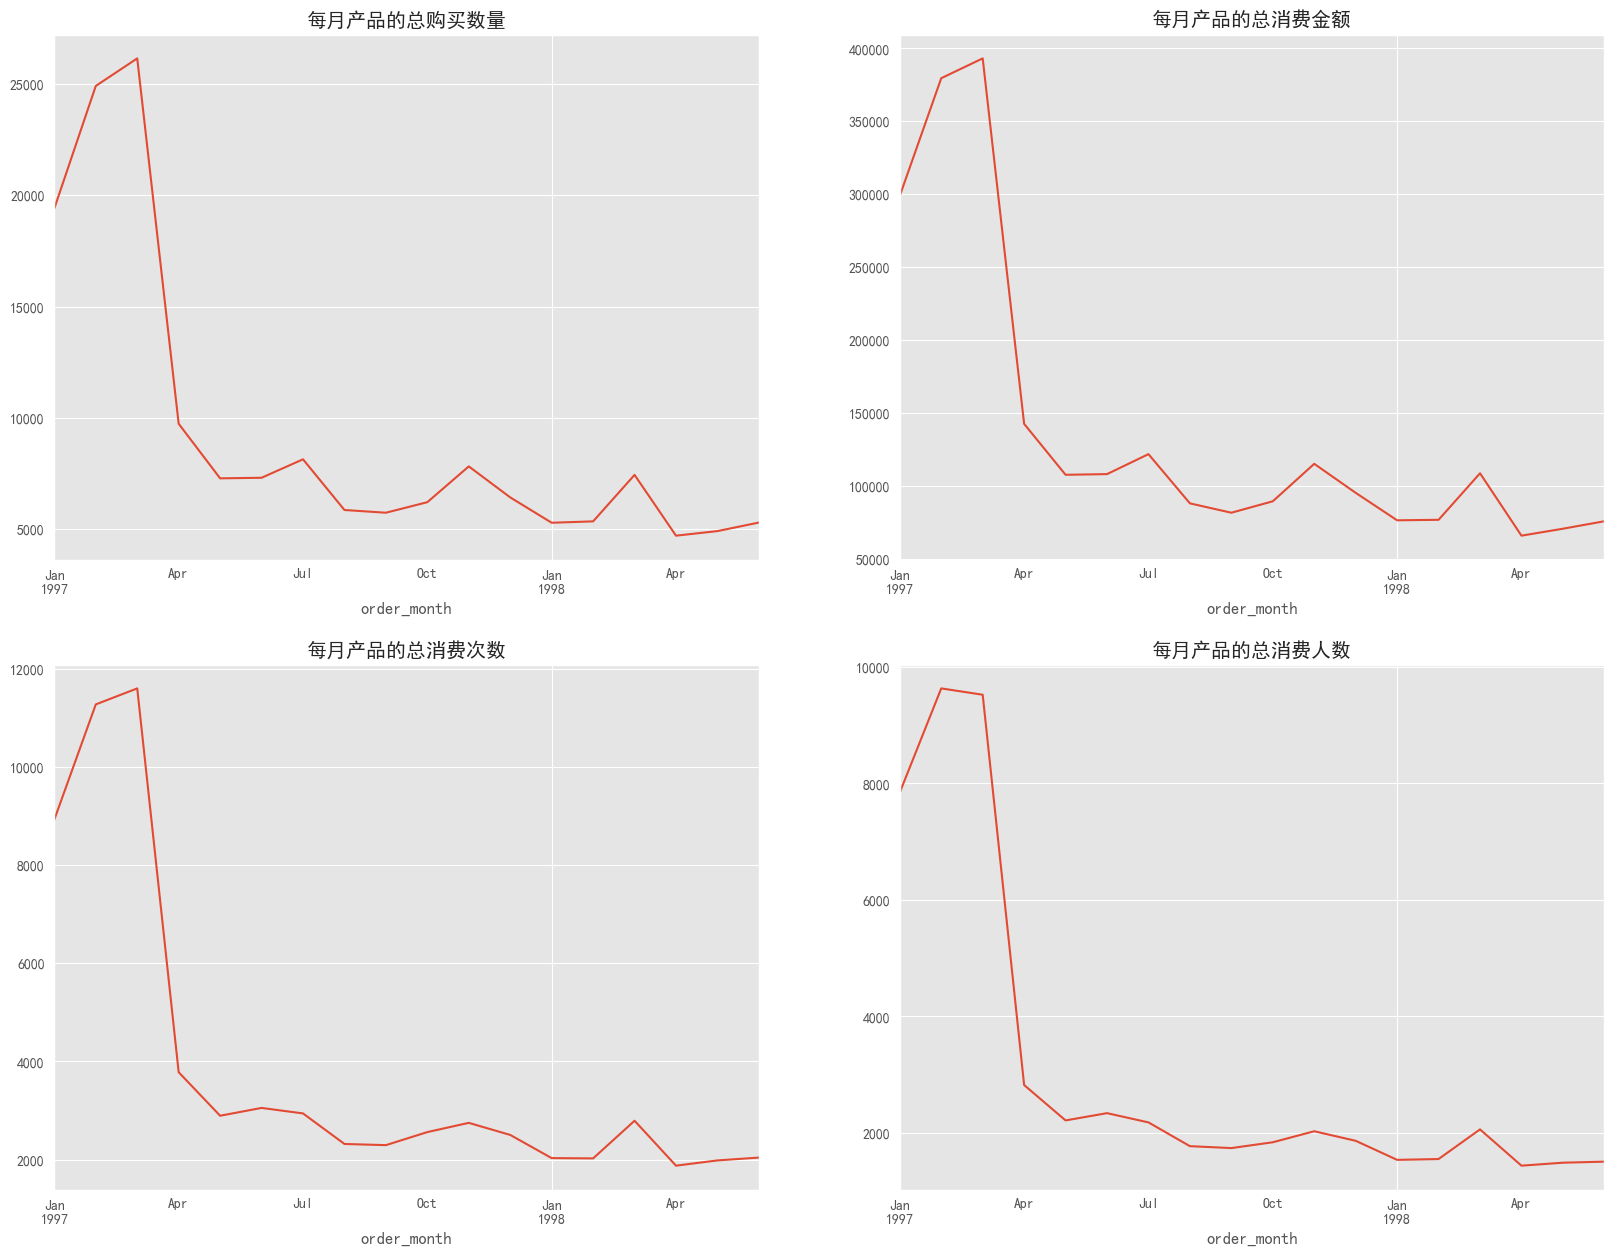

In [6]:
# 创建画布
plt.figure(figsize=(20, 15))

# 1. 按月统计产品的总购买数量
# 创建2行2列的子画布，并存放在第一个位置
plt.subplot(2, 2, 1)
df.groupby(by=["order_month"])["products_num"].sum().plot()
plt.title("每月产品的总购买数量")

# 2. 按月统计产品的总消费金额
# 创建2行2列的子画布，并存放在第二个位置
plt.subplot(2, 2, 2)
df.groupby(by=["order_month"])["order_amount"].sum().plot()
plt.title("每月产品的总消费金额")

# 3. 按月统计产品的消费次数
# 创建2行2列的子画布，并存放在第三个位置
plt.subplot(2, 2, 3)
df.groupby(by=["order_month"])["user_id"].count().plot()
plt.title("每月产品的总消费次数")

# 4. 按月统计产品的总消费人数，区别第三点是要去重再统计
# 创建2行2列的子画布，并存放在第四个位置
plt.subplot(2, 2, 4)
# 注意分组后取出来的'user_id'是Series类型的数据，没有drop_duplicates()方法，可通过apply()方法进行类型错误处理，
# 这里搭配lambda表达式来去重并判断其长度即可
df.groupby(by="order_month")['user_id'].apply(lambda x: len(x.drop_duplicates())).plot()
plt.title("每月产品的总消费人数")

plt.show()

### 3. 用户整体消费分析结论：
* 图一可以看出，前三个月销量非常高，而之后的销量较为稳定，并且稍微呈现下降趋势
* 图二可以看出，依然前三个月消费金额较高，与前面的消费次数成正比例关系，三月份过后下降严重，并呈现下降趋势
* 图三可以看出，前三个月订单数在10000左右，后续月份的平均消费单数在2500左右
* 图四可以看出，前三个月消费人数在8000~10000左右，后续平均消费在2000左右的样子
* 思考该结论的原因？可能跟月份有关，在我国1，2，3月份处于春节前后，公司可能在这些月份的时候是否加大了促销力度
* 总结：所有数据图表的显示，97年前三月消费事态异常(并非不好的异常)，后续趋于常态化(平稳)

### 四、用户个体消费分析
##### 分析目标：
* 4-1. 主要分析用户的总消费金额和购买总商品数量的大体情况
* 4-2. 主要分析每个用户总购买数量和每次的消费金额的分布情况，集中在哪些区间？
* 4-3. 主要分析用户的累计消费金额在总的消费金额中的累计贡献率/占比情况，注意是‘当前用户和它之前的所有用户的累计金额’和‘整体所有用户总金额’相除，而不是求单个用户的总金额在所有用户的总金额中的占比，先按照每个用户的总金额来排序再求

#### 4-1. 每个用户的总消费金额和购买的总商品数量描述性统计

In [7]:
# 每个用户的总消费金额
user_group_amount = df.groupby(by='user_id')['order_amount'].sum()
print(user_group_amount.describe())

# 每个用户的购买总商品数量
user_group_products_num = df.groupby(by='user_id')['products_num'].sum()
print(f"总用户数量为：{len(user_group_products_num)}")
print(user_group_products_num.describe())

count    23570.000000
mean       106.080426
std        240.925195
min          0.000000
25%         19.970000
50%         43.395000
75%        106.475000
max      13990.930000
Name: order_amount, dtype: float64
总用户数量为：23570
count    23570.000000
mean         7.122656
std         16.983531
min          1.000000
25%          1.000000
50%          3.000000
75%          7.000000
max       1033.000000
Name: products_num, dtype: float64


#### 4-1-1. 描述性统计分析结论：
* 从用户角度： 用户数量总共有23570人，平均数看出每个用户平均购买7个产品，但是中位数只有3，并且最大购买量为1033，平均值大于中位数，属于典型的右偏分布；
* 从消费金额角度： 用户平均消费106元，中位数为43，并且存在土豪用户消费最大金额为13990元，结合分位数和最大值来看，平均数与75%分位数几乎相等，也属于典型的右偏分布，说明存在小部分用户（后面的25%）高额消费

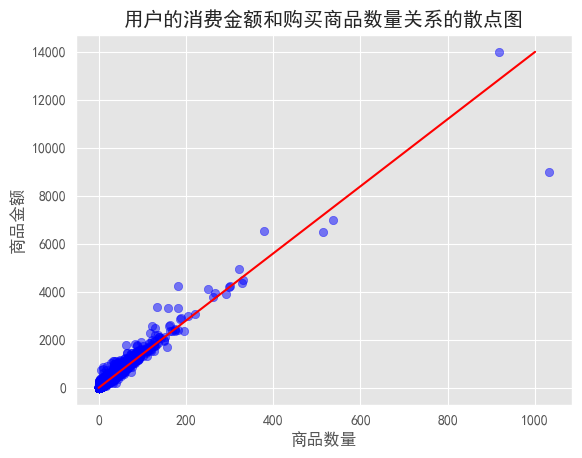

In [8]:
# 可视化-散点图，分析用户总金额和总数量的相关性
plt.scatter(user_group_products_num, user_group_amount, color='blue', alpha=0.5)
plt.xlabel("商品数量")
plt.ylabel("商品金额")
plt.title("用户的消费金额和购买商品数量关系的散点图")
plt.plot([0, 1000], [0, 14000], color='red')  # 回归线

#### 4-1-2. 以上绘制的散点图结论：
* 从图中可知，用户的消费金额与购买量呈现线性趋势，两数相除可知每个商品大概均价15元左右；订单的极值点比较少（消费金额>14000，或者购买量大于1000）,对于样本来说影响不大，可以忽略不记。

### 4-2. 用户消费分布情况分析(每个用户总购买数量和每次的金额)

Text(0.5, 0, '购买数量')

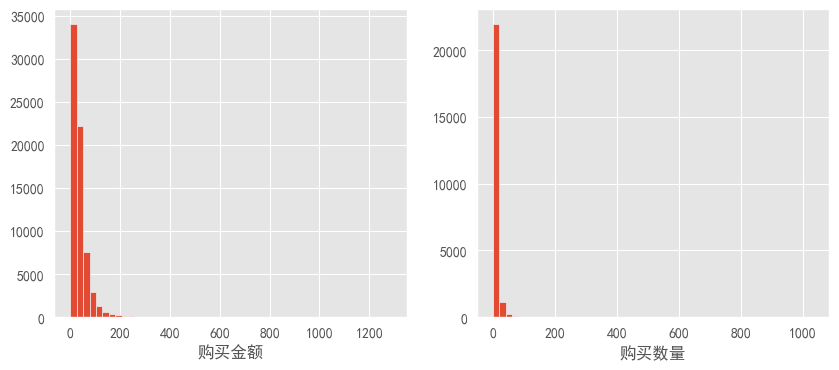

In [9]:
# 4-2-1. 每个用户每次购买的金额分布情况分析，分析金额主要集中在哪个区间？
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df["order_amount"], bins=50)
plt.xlabel("购买金额")

# 4-2-2. 每个用户购买产品的总数量分布情况分析
user_products_num = df.groupby(by="user_id")["products_num"].sum()
plt.subplot(1, 2, 2)
plt.hist(user_products_num, bins=50)
plt.xlabel("购买数量")

#### 4-2. 用户消费分布情况分析结论：
* 图一：消费金额在100以内的订单占据了绝大多数
* 图二：每个用户购买数量都非常小，主要集中在50件左右
* 由以上两幅图得知，购买产品的用户主要是消费金额低，并且购买产品数量小于50的占大多数（在电商领域是非常正常的现象）

### 4-3. 用户累计消费金额占比分析（用户的累计贡献率）
* 这里要求用户的累计消费金额在总的消费金额中的贡献率，注意是当前用户和之前的所有用户的累计金额，而不是求单个用户的总金额在所有用户的总金额中的占比

In [10]:
# 求每个用户消费的总金额
user_all_order_amount = df.groupby(by=df["user_id"])["order_amount"].sum().sort_values().reset_index()
user_all_order_amount

,user_id,order_amount
0,16921,0.00
1,713,0.00
2,9835,0.00
3,7005,0.00
4,1948,0.00
...,...,...
23565,7931,6497.18
23566,19339,6552.70
23567,7983,6973.07
23568,14048,8976.33


In [11]:
# 求累加金额并添加新列，通过累加器np.cumsum来求
user_all_order_amount["cumsum_amount"] = np.cumsum(user_all_order_amount["order_amount"])
# 求消费最大的金额
Allamount_MAX = user_all_order_amount["cumsum_amount"].max()
# 求贡献率prop，并添加新列                                 注意是用‘当前用户和它之前的所有用户的累计金额’和‘整体所有的总金额相除’
user_all_order_amount["prop"] = user_all_order_amount.apply(lambda x: x["cumsum_amount"] / Allamount_MAX, axis=1)
user_all_order_amount

,user_id,order_amount,cumsum_amount,prop
0,16921,0.00,0.00,0.000000
1,713,0.00,0.00,0.000000
2,9835,0.00,0.00,0.000000
3,7005,0.00,0.00,0.000000
4,1948,0.00,0.00,0.000000
...,...,...,...,...
23565,7931,6497.18,2463822.60,0.985405
23566,19339,6552.70,2470375.30,0.988025
23567,7983,6973.07,2477348.37,0.990814
23568,14048,8976.33,2486324.70,0.994404


Text(0, 0.5, '占比')

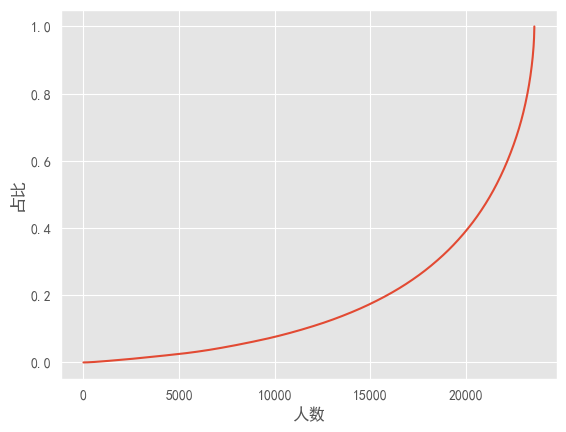

In [12]:
# 绘折线图
plt.plot(user_all_order_amount["prop"])
plt.xlabel("人数")
plt.ylabel("占比")

#### 4-3. 贡献率的折线图结论：
* 按每个用户总金额排序后，前20000名用户总金额的贡献率为40%，而剩余的用户贡献了60%。（是常见的二八分布，即20%的用户贡献80%的收入）

### 五、用户分层分析
分析目标：
* 5-1. 通过构建RFM模型来分析用户的价值指数，重要/一般价值客户较多或较少等情况
* 5-2. 新用户、活跃用户、不活跃用户、回流用户分析

#### 5-1. 构建RFM模型

In [13]:
# 构建透视表并存放到RFM中，index：相当于groupby；values：是取出的数据列；aggfunc：对指定列进行聚合运算，key值必须存在于values列中
rfm = df.pivot_table(
    index="user_id",
    values=["products_num", "order_amount", "order_date_new"],
    aggfunc={
        "products_num": "sum",
        "order_amount": "sum",
        "order_date_new": "max",  # 求最后一次购买时间
    }
)
# 求 RFM模型中的R，用每个用户的最后一次购买时间-所有用户日期列中的最大值，最后再转换成天数，小数保留一位，结果是负数要取反
rfm["R"] = -(rfm["order_date_new"] - rfm["order_date_new"].max()) / np.timedelta64(1, "D")
# 或者通过以下方式直接把日期转为天数即可
# rfm["R"] = -(rfm["order_date_new"] - rfm["order_date_new"].max()).dt.days

# 这里规定每个用户消费的总金额为M，购买的产品总数量为F，所以直接重命名rfm中的列
rfm.rename(columns={"order_amount": "M", "products_num": "F"}, inplace=True)
rfm

,M,order_date_new,F,R
user_id,,,,
1,11.77,1997-01-01,1,545.0
2,89.00,1997-01-12,6,534.0
3,156.46,1998-05-28,16,33.0
4,100.50,1997-12-12,7,200.0
5,385.61,1998-01-03,29,178.0
...,...,...,...,...
23566,36.00,1997-03-25,2,462.0
23567,20.97,1997-03-25,1,462.0
23568,121.70,1997-04-22,6,434.0


In [14]:
# 客户等级划分
# RFM代号(如100、111)计算方式：每一列数据减去数据所在当前列的平均值，有正有负，根据结果值与1做比较，如果>=1,设置为1，否则为0

# 自定义一个函数，给下面调用
def rfm_func(x):  # x:分别代表rfm[["R", "F", "M"]]中的每一条数据
    level = x.apply(lambda x: "1" if x >= 1 else "0")  # 对每一条中的每个数据项进行判断并返回1或0，形成新的DataFrame
    label = level["R"] + level["F"] + level["M"]  # 取出上面新的DataFrame里面的每一列数据并做拼接
    my_dict = {  # 定义字典来存放代号对应的等级
        '111': '重要价值客户',
        '011': '重要保持客户',
        '101': '重要发展客户',
        '001': '重要挽留客户',
        '110': '一般价值客户',
        '010': '一般保持客户',
        '100': '一般发展客户',
        '000': '一般挽留客户'
    }
    return my_dict[label]  # 通过K值label在字典中取数并返回等级相关的数据

# 取rfm中的3列["R", "F", "M"]数据项，并通过计算后添加新列
rfm["label"] = rfm[["R", "F", "M"]].apply(lambda x: x - x.mean()).apply(rfm_func, axis=1)
rfm

,M,order_date_new,F,R,label
user_id,,,,,
1,11.77,1997-01-01,1,545.0,一般发展客户
2,89.00,1997-01-12,6,534.0,一般发展客户
3,156.46,1998-05-28,16,33.0,重要保持客户
4,100.50,1997-12-12,7,200.0,一般挽留客户
5,385.61,1998-01-03,29,178.0,重要保持客户
...,...,...,...,...,...
23566,36.00,1997-03-25,2,462.0,一般发展客户
23567,20.97,1997-03-25,1,462.0,一般发展客户
23568,121.70,1997-04-22,6,434.0,重要发展客户


Text(0, 0.5, 'R每个用户最近一次购买时间与98年7月的相差天数')

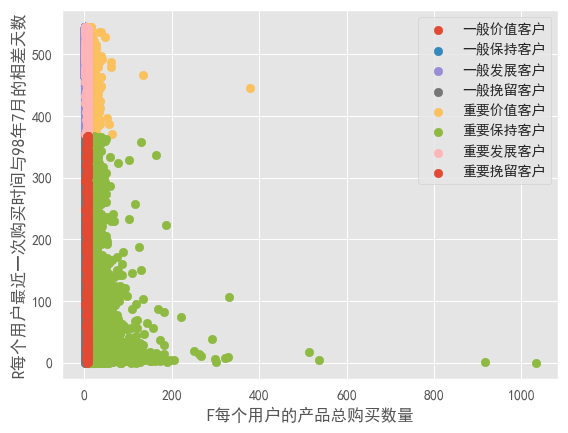

In [15]:
# 用户分层分析可视化-散点图
# 通过rfm中的等级列"label"来分组，并遍历每一组
for label, grouped in rfm.groupby("label"):
    # 设定X轴和Y轴的数据值，这里主要是为了直观看到大体的客户等级数量情况，所以X轴和Y轴的数据值取值不重要
    x = grouped["F"]  # 每个用户的产品总购买数量，做为x轴
    y = grouped["R"]  # 每个用户最近一次购买时间与98年7月的相差天数，做为y轴
    plt.scatter(x, y, label=label)  # 通过属性label设置图例标签值

plt.legend()  #显示图例
plt.xlabel('F每个用户的产品总购买数量')
plt.ylabel('R每个用户最近一次购买时间与98年7月的相差天数')

#### 5-1. 构建RFM模型分析结论：
* 通过该散点图观察得知：购买该产品的“重要保持客户”普遍较多(绿色的点)，而“一般挽留客户”较少(灰色的点)

### 5-2. 新用户、活跃用户、不活跃用户、回流用户分析
1. 新用户，第一次消费
2. 活跃用户，在连续的时间窗口内有过消费（时间窗口：某一段时间，例如每个月之间）
3. 不活跃用户，在时间窗口内没有消费过的用户，没有连续消费
4. 回流用户，隔了几个时间窗口再次回来产生消费的用户；用户回流的动作可以分为自主回流与人工回流，自主回流指用户自己回流了，而人工回流则是人为参与导致的

In [16]:
# 先通过透视表从原来的数据df中做每月每个用户的消费次数的统计
pivoted_counts = df.pivot_table(
    index="user_id",          # 以该列来分组
    columns="order_month",    # 取月份的列
    values="order_date_new",  # 取该列并做聚合运算
    aggfunc="count"           # 对order_date_new列做统计次数运算
).fillna(0)                   # 还对所有的空值做了0填充

pivoted_counts

order_month,1997-01,1997-02,1997-03,1997-04,1997-05,1997-06,1997-07,1997-08,1997-09,1997-10,1997-11,1997-12,1998-01,1998-02,1998-03,1998-04,1998-05,1998-06
user_id,,,,,,,,,,,,,,,,,,
1,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,2.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
5,2.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,2.0,1.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23566,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23567,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
23568,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
# 在此每个用户的消费次数不重要，看是否有消费即可，把上面pivoted_counts中有消费次数的赋值为1，没有消费次数的赋值为0，并赋值给新的DataFrame
df_purchase = pivoted_counts.map(lambda x: 1 if x > 0 else 0)  # applymap()函数提示已被弃用，直接用map()来对每个元素进行映射处理即可
df_purchase

order_month,1997-01,1997-02,1997-03,1997-04,1997-05,1997-06,1997-07,1997-08,1997-09,1997-10,1997-11,1997-12,1998-01,1998-02,1998-03,1998-04,1998-05,1998-06
user_id,,,,,,,,,,,,,,,,,,
1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,1,0,1,1,0,0,0,0,0,0,1,0,0,0,0,0,1,0
4,1,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0
5,1,1,0,1,1,1,1,0,1,0,0,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23566,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23567,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
23568,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [18]:
# 判断是否是新用户、活跃用户、不活跃用户、回流用户
# 用户状态说明：
# 1. unreg未注册用户：一直没有消费过的
# 2. new新用户：第一次消费的
# 3. active活跃用户：上一个月和当月都消费
# 4. unactive不活跃用户：上一个月消费，而当月没有消费
# 5. return回流用户：隔离一段时间后再次消费

# 自定义函数给下面调用，data是每条用户数据
def active_status(data):
    status = []    #定义列表存储用户18个月的状态（unreg|new|active|unactive|return）
    for i in range(18):
        #本月没有消费情况，0
        if data[i] == 0:
            if len(status) == 0:  # 判断之前有没有记录
                status.append('unreg')
            else:   # 之前有记录，判断上一个月状态
                if status[i - 1] == 'unreg':
                    status.append('unreg')
                else:  # 上个月的状态可能是：new|active|unative|reuturn
                    status.append('unactive')
        #本月有消费情况，1
        else:
            if len(status) == 0:
                status.append('new')  #第一次消费
            else:   # 之前有记录，判断上一个月状态
                if status[i - 1] == 'unactive':
                    status.append('return')  # 前几个月不活跃，现在又回来消费了，是回流用户
                elif status[i - 1] == 'unreg':
                    status.append('new')     # 第一次消费
                else:  # 上一个月可能是new|active
                    status.append('active')  # 活跃用户

    return pd.Series(status, df_purchase.columns)  # 要通过Series的形式返回，并使用df_purchase中的月份做为列名

purchase_states = df_purchase.apply(active_status, axis=1)
purchase_states.head()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16736\852674404.py:14: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data[i] == 0:


order_month,1997-01,1997-02,1997-03,1997-04,1997-05,1997-06,1997-07,1997-08,1997-09,1997-10,1997-11,1997-12,1998-01,1998-02,1998-03,1998-04,1998-05,1998-06
user_id,,,,,,,,,,,,,,,,,,
1,new,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive
2,new,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive,unactive
3,new,unactive,return,active,unactive,unactive,unactive,unactive,unactive,unactive,return,unactive,unactive,unactive,unactive,unactive,return,unactive
4,new,unactive,unactive,unactive,unactive,unactive,unactive,return,unactive,unactive,unactive,return,unactive,unactive,unactive,unactive,unactive,unactive
5,new,active,unactive,return,active,active,active,unactive,return,unactive,unactive,return,active,unactive,unactive,unactive,unactive,unactive


In [19]:
# 统计每种状态的数量情况
# 先把unreg未注册的用户替代为NaN，方便后续做可视化
purchase_states_conut = purchase_states.replace("unreg", np.nan).apply(lambda x: pd.value_counts(x))
purchase_states_conut.head()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16736\38240093.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  purchase_states_conut = purchase_states.replace("unreg", np.nan).apply(lambda x: pd.value_counts(x))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16736\38240093.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  purchase_states_conut = purchase_states.replace("unreg", np.nan).apply(lambda x: pd.value_counts(x))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16736\38240093.py:3: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  purchase_states_conut = purchase_states.replace("unreg", np.nan).apply(lambda x: pd.value_counts(x))
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16736\38240093.py:3: 

order_month,1997-01,1997-02,1997-03,1997-04,1997-05,1997-06,1997-07,1997-08,1997-09,1997-10,1997-11,1997-12,1998-01,1998-02,1998-03,1998-04,1998-05,1998-06
active,NaN,1157.0,1681,1773.0,852.0,747.0,746.0,604.0,528.0,532.0,624.0,632.0,512.0,472.0,571.0,518.0,459.0,446.0
new,7846.0,8476.0,7248,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
return,NaN,NaN,595,1049.0,1362.0,1592.0,1434.0,1168.0,1211.0,1307.0,1404.0,1232.0,1025.0,1079.0,1489.0,919.0,1029.0,1060.0
unactive,NaN,6689.0,14046,20748.0,21356.0,21231.0,21390.0,21798.0,21831.0,21731.0,21542.0,21706.0,22033.0,22019.0,21510.0,22133.0,22082.0,22064.0


<Axes: xlabel='order_month'>

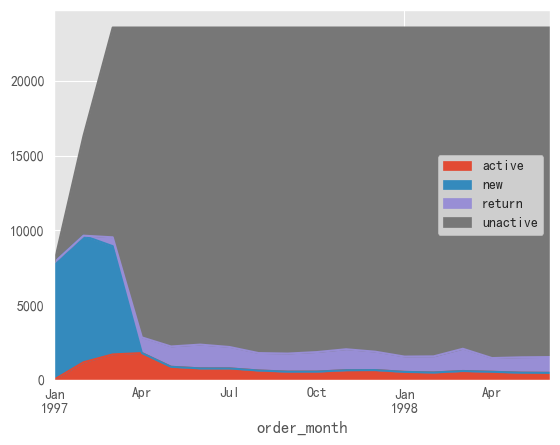

In [20]:
# 把NaN的数据填充为0，并进行行列转置一下，方便做可视化--面积图
purchase_states_conut.fillna(0).T.plot.area()

#### 5-2. 新用户、活跃用户、不活跃用户、回流用户分析可视化结论：
* 由面积图可知：灰色区域的不活跃用户，占比最大
* 前三个月蓝色的新用户和红色的活跃用户都呈现了上升趋势，猜测是由于促销活动造成的影响
* 3月份过后，紫色的回流用户、红色的活跃用户和蓝色的新用户，都呈现下降趋势，并且趋于平稳状态，猜测是活动力度减缓的影响

### 六、用户购买周期分析
* 分析目标：用户购买周期分布情况，平均是多久的以及占比情况，以便针对购买周期较长的用户进行相应的宣传等活动
* 购买周期：本次购买时间和上一次的购买时间间隔，可有多个购买周期

In [21]:
# 可通过shift()函数获取下一个数据项，它默认会往后移动一个位置，也可以通过axis来控制，如下使用示例：
data1 = pd.DataFrame({
    'a': [0, 1, 2, 3, 4, 5],
    'b': [5, 4, 3, 2, 1, 0]
})
print(data1)
print(data1.shift(axis=0))  # 整体的数据项向下移动一个位置（默认的）
print(data1.shift(axis=1))  # 整体的数据项向右移动一个位置

   a  b
0  0  5
1  1  4
2  2  3
3  3  2
4  4  1
5  5  0
     a    b
0  NaN  NaN
1  0.0  5.0
2  1.0  4.0
3  2.0  3.0
4  3.0  2.0
5  4.0  1.0
    a  b
0 NaN  0
1 NaN  1
2 NaN  2
3 NaN  3
4 NaN  4
5 NaN  5


In [22]:
# 求用户相邻两个购买日期之差
order_diff = df.groupby(by="user_id").apply(lambda x: x["order_date_new"] - x["order_date_new"].shift())
order_diff.head()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16736\3646936789.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  order_diff = df.groupby(by="user_id").apply(lambda x: x["order_date_new"] - x["order_date_new"].shift())


user_id   
1        0       NaT
2        1       NaT
         2    0 days
3        3       NaT
         4   87 days
Name: order_date_new, dtype: timedelta64[ns]

In [23]:
order_diff.describe()  # 描述性统计信息

count                         46089
mean     68 days 23:22:13.567662566
std      91 days 00:47:33.924168892
min                 0 days 00:00:00
25%                10 days 00:00:00
50%                31 days 00:00:00
75%                89 days 00:00:00
max               533 days 00:00:00
Name: order_date_new, dtype: object

Text(0, 0.5, '人数')

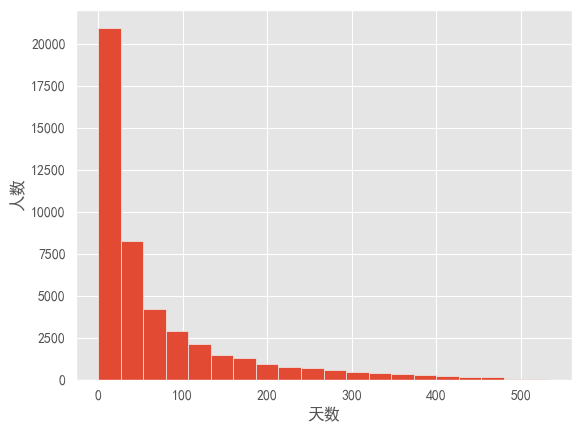

In [24]:
# 可视化--直方图
# 需先把周期转换为日期天数，方便做为数据轴显示
(order_diff / np.timedelta64(1, 'D')).hist(bins=20)
plt.xlabel("天数")
plt.ylabel("人数")

#### 6. 用户购买周期分析结论：
* 由描述性统计结果得知：用户的平均消费周期为68天
* 由四分之三中位数可知大多数用户消费周期低于100天
* 直方图呈现典型的长尾分布，只有小部分用户消费周期在200天以上（也是不积极消费的用户），后续可以在这批用户消费后3天左右进行电话回访后者短信
赠送优惠券等活动，以增大消费频率

### 七、用户生命周期分析
* 分析目标：分析只消费一次和消费多次的用户占比情况，以及分析要对哪部分用户进行加强宣传
* 生命周期：用户最后一次购买日期(max) - 第一次购买的日期(min)，如果差值==0，说明用户仅仅购买了一次

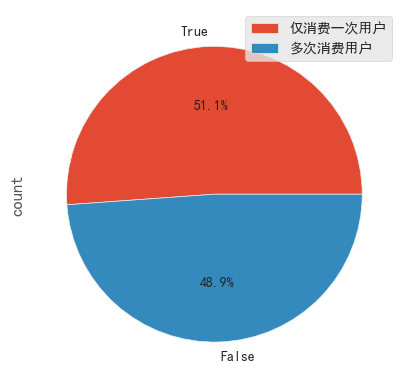

In [25]:
# 7-1. 仅消费一次用户和有多次消费用户比例分析
user_life = df.groupby(by="user_id")['order_date_new'].agg(['min', 'max'])
count_v1 = (user_life['max'] == user_life['min']).value_counts()
# 数量统计结果为：True是只消费一次的用户数量，False是有多次消费的用户数量
# True     12054
# False    11516
# Name: count, dtype: int64

# 绘制饼图查看两者的比例情况
count_v1.plot.pie(autopct='%.1f%%')
plt.legend(['仅消费一次用户', '多次消费用户'])

#### 7-1. 仅消费一次用户和有多次消费用户比例分析结论：
* 由饼图可知：有一半以上的用户仅仅消费了一次，说明运营不好，留存率不行

In [26]:
# 7-2. 所有用户生命周期的描述性统计
(user_life['max'] - user_life['min']).describe()

count                          23570
mean     134 days 20:55:36.987696224
std      180 days 13:46:43.039788102
min                  0 days 00:00:00
25%                  0 days 00:00:00
50%                  0 days 00:00:00
75%                294 days 00:00:00
max                544 days 00:00:00
dtype: object

#### 7-2. 描述性统计结论：
* 所有用户的平均生命周期为134天，但是中位数==0，再次验证了大多数用户只消费了一次，属于低质量用户；而75%分位数以后的用户，生命周期>294天，属于核心用户，需要着重维持

       user_id        0
0            1   0 days
1            2   0 days
2            3 511 days
3            4 345 days
4            5 367 days
...        ...      ...
23565    23566   0 days
23566    23567   0 days
23567    23568  28 days
23568    23569   0 days
23569    23570   1 days

[23570 rows x 2 columns]


Text(0, 0.5, '用户人数')

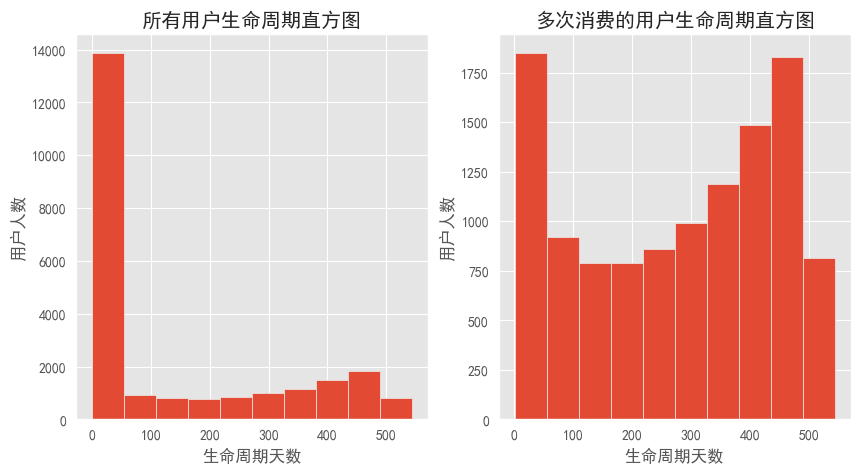

In [27]:
# 7-3. 绘直方图
# 7-3-1. 对所有用户的生命周期分析
user_v1 = (user_life['max'] - user_life['min']) / np.timedelta64(1, 'D')
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
user_v1.plot.hist()
plt.title('所有用户生命周期直方图')
plt.xlabel('生命周期天数')
plt.ylabel('用户人数')

# 7-3-2. 只对有多次消费用户绘图分析
plt.subplot(1, 2, 2)
user_v2 = (user_life['max'] - user_life['min']).reset_index()
print(user_v2)  # 对差值数据重置索引后要的日期数据在列名为0的列，如下输出
#   user_id	  0
# 0	   1	  0 days
# 1	   2	  0 days
#......
user_v3 = user_v2[0] / np.timedelta64(1, 'D')  # 只取日期列并转换为天数
user_v3[user_v3 > 0].plot.hist()  # 通过布尔索引取出多次消费的用户并绘图
plt.title('多次消费的用户生命周期直方图')
plt.xlabel('生命周期天数')
plt.ylabel('用户人数')

#### 7-3. 绘制直方图结论：
* 两图对比可知，第二幅图过滤掉了生命周期==0的用户，呈现双峰结构
* 虽然图二中还有一部分用户的生命周期趋于0天，但是比第一幅图好很多，虽然进行了多次消费，但它是不成长期来消费，属于普通用户，可针对性进行营销推广活动
* 少部分用户生命周期集中在300~500天，属于我们的忠诚客户，需要大力度维护此类客户

### 八、用户复购率分析
* 复购率计算方式：这里规定在自然一个月内，当月有多次购买的用户数量在当月有消费的总人数中的占比（若一个客户在同一天消费了多次，也称之复购用户）

这里消费者分为以下三种：
1. 当月消费次数>=2的(是复购用户，而只有一次的是新用户不是复购用户)
2. 消费中的？？？？
3. 本月无消费的

In [28]:
# 这里直接采用上面5-2的数据pivoted_counts即可，它已从原来的数据中统计出每月的消费次数
# 当月消费次数>=2的是复购用户，而只有一次的是新用户不是复购用户

# 数据处理，复购用户用1表示；非复购但有消费用户用0表示；没有任何消费记录的用户用NAN表示(注意NAN是不参与count计数运算的)
purchase_rplay = pivoted_counts.map(lambda x: 1 if x > 1 else np.nan if x == 0 else 0)
purchase_rplay

order_month,1997-01,1997-02,1997-03,1997-04,1997-05,1997-06,1997-07,1997-08,1997-09,1997-10,1997-11,1997-12,1998-01,1998-02,1998-03,1998-04,1998-05,1998-06
user_id,,,,,,,,,,,,,,,,,,
1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN
4,1.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
5,1.0,0.0,NaN,0.0,0.0,0.0,0.0,NaN,0.0,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23566,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23567,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23568,NaN,NaN,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# 求出每月的复购用户，由于默认axis=0，会一列一列地运算，所以直接求即可
purchase_rplay.sum()

order_month
1997-01     844.0
1997-02    1178.0
1997-03    1479.0
1997-04     631.0
1997-05     436.0
1997-06     458.0
1997-07     469.0
1997-08     355.0
1997-09     352.0
1997-10     380.0
1997-11     410.0
1997-12     410.0
1998-01     324.0
1998-02     315.0
1998-03     473.0
1998-04     286.0
1998-05     298.0
1998-06     323.0
Freq: M, dtype: float64

In [30]:
# 求出所有参与购物的用户(只包括所有有消费次数的，注意NAN的数据是不参与count计数运算的)
purchase_rplay.count()

order_month
1997-01    7846
1997-02    9633
1997-03    9524
1997-04    2822
1997-05    2214
1997-06    2339
1997-07    2180
1997-08    1772
1997-09    1739
1997-10    1839
1997-11    2028
1997-12    1864
1998-01    1537
1998-02    1551
1998-03    2060
1998-04    1437
1998-05    1488
1998-06    1506
Freq: M, dtype: int64

<Axes: xlabel='order_month'>

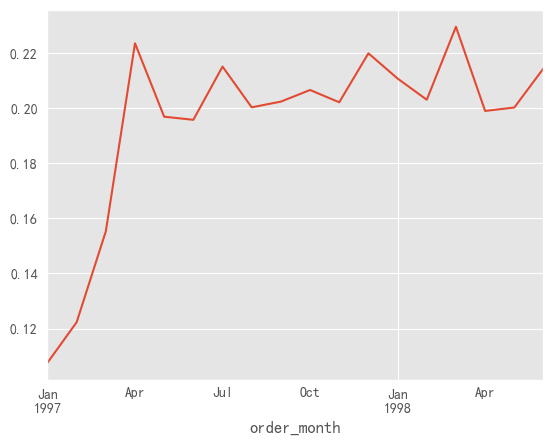

In [31]:
# 绘制折线图
(purchase_rplay.sum() / purchase_rplay.count()).plot()

#### 8. 结论：
* 由折线图可知前三个月复购率是上升状态，后续趋于平稳维持在20%~22%之间
* 分析前三个月复购率低的原因：可能是因为大批的新用户仅仅购买一次造成的

### 九、用户回购率分析
* 分析目标：用户当月回购率的大体情况；回购率和复购率的对比情况；回购人数和复购人数的对比情况
* 回购率计算方式：在一个时间窗口(这里设定为一个月)内进行了消费，在下一个窗口内又进行了消费

In [32]:
# 这里也直接使用5-2的数据df_purchase，它已经计算好用户在每个月是否有消费，有消费次数的赋值为1，没有消费次数的赋值为0
def purchase_back(data):
    status = []  # 用于存储是否是回购用户的状态
    # 1代表是回购用户；0代表是非回购用户（当前月消费了，下个未消费），而NaN代表当前月份未消费
    for i in range(17):
        # 当月有消费，1的情况
        if data[i] == 1:
            if data[i + 1] == 1:
                status.append(1)  # 回购用户
            else:
                status.append(0)  # 非回购用户
        # 当月没有消费，0情况
        else:
            status.append(np.nan)
    status.append(np.nan)  # 填充最后一列数据做补全列而已
    return pd.Series(status, df_purchase.columns)

purchase_b = df_purchase.apply(purchase_back, axis=1)
purchase_b

C:\Users\Administrator\AppData\Local\Temp\ipykernel_16736\520153296.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data[i] == 1:
C:\Users\Administrator\AppData\Local\Temp\ipykernel_16736\520153296.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if data[i + 1] == 1:


order_month,1997-01,1997-02,1997-03,1997-04,1997-05,1997-06,1997-07,1997-08,1997-09,1997-10,1997-11,1997-12,1998-01,1998-02,1998-03,1998-04,1998-05,1998-06
user_id,,,,,,,,,,,,,,,,,,
1,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0.0,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN
4,0.0,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
5,1.0,0.0,NaN,1.0,1.0,1.0,0.0,NaN,0.0,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23566,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23567,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
23568,NaN,NaN,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
# 计算每个月的回购用户
purchase_b.sum()

order_month
1997-01    1157.0
1997-02    1681.0
1997-03    1773.0
1997-04     852.0
1997-05     747.0
1997-06     746.0
1997-07     604.0
1997-08     528.0
1997-09     532.0
1997-10     624.0
1997-11     632.0
1997-12     512.0
1998-01     472.0
1998-02     571.0
1998-03     518.0
1998-04     459.0
1998-05     446.0
1998-06       0.0
Freq: M, dtype: float64

In [34]:
# 计算每个月有消费记录的所有用户(包括1和0状态的数据)
purchase_b.count()

order_month
1997-01    7846
1997-02    9633
1997-03    9524
1997-04    2822
1997-05    2214
1997-06    2339
1997-07    2180
1997-08    1772
1997-09    1739
1997-10    1839
1997-11    2028
1997-12    1864
1998-01    1537
1998-02    1551
1998-03    2060
1998-04    1437
1998-05    1488
1998-06       0
Freq: M, dtype: int64

Text(0.5, 1.0, '用户的回购率和复购率对比图')

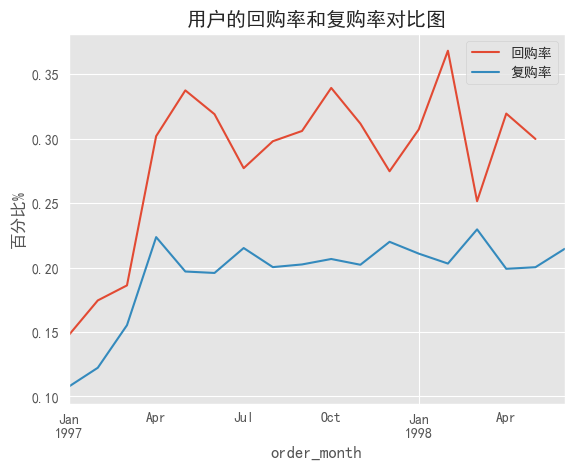

In [35]:
# 可视化，还和上面的复购率做了折线图对比
# 回购率折线图
(purchase_b.sum() / purchase_b.count()).plot(label='回购率')
# 复购率折线图
(purchase_rplay.sum() / purchase_rplay.count()).plot(label='复购率')
plt.legend()
plt.ylabel('百分比%')
plt.title('用户的回购率和复购率对比图')

#### 回购率结论：
* 由以上折线图可知可知，回购率平稳后大体维持在30%左右，波动较大
* 复购率都低于回购率，复购率平稳后在大体维持20%左右，波动较小
* 两者在前三个月，都呈现上升趋势，说明新用户需要一定时间来转变成复购或者回购者

Text(0.5, 1.0, '回购人数与总购物人数对比图')

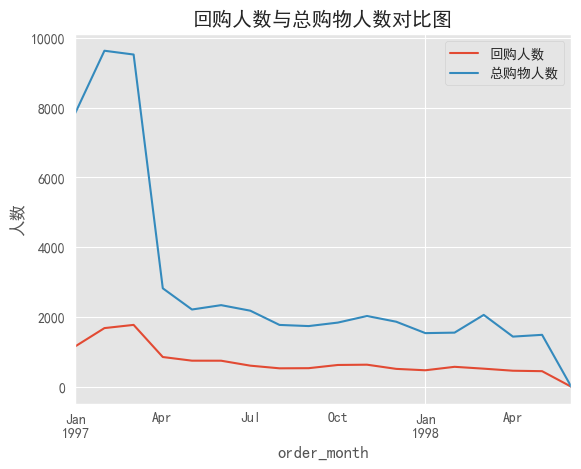

In [36]:
# 再分析一下回购人数与总购物人数情况
purchase_b.sum().plot(label='回购人数')
purchase_b.count().plot(label='总购物人数')
plt.legend()
plt.ylabel('人数')
plt.title('回购人数与总购物人数对比图')

#### 回购人数与总购物人数折线图对比结论：
* 前三个月总购物人数远远大于回购人数，主要是因为很多新用户在1月份进了首次购买
* 三个月后，回购人数和购物总数开始稳定，回购人数稳定在1000左右，总购物人数在2000左右